# TFM_00_Master_Template: Plantilla de Control Multi-Planta con RL y MLflow

**Objetivo:** Este notebook contiene la estructura base para el entrenamiento de agentes de Reinforcement Learning (RL) en el entorno `ThreePlantEnv`, asegurando el registro sistemático de experimentos y métricas mediante **MLflow**.

## 1) Instalación e Importaciones

In [8]:
# ====================================================================
# I. INSTALACIÓN E IMPORTACIONES
# ====================================================================
# Descomenta la siguiente línea si necesitas instalar las librerías
# %pip install stable-baselines3[extra] gymnasium matplotlib pandas shimmy mlflow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

# Librerías de RL
from stable_baselines3 import PPO, TD3, SAC
from stable_baselines3.common.monitor import Monitor # CRUCIAL para logs

# MLflow
import mlflow
from mlflow.tracking import MlflowClient

# Configuración de gráficos
plt.style.use('ggplot')
print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


## 2) Configuración de MLflow

In [9]:
# ====================================================================
# II. CONFIGURACIÓN DE MLFLOW
# ====================================================================
EXPERIMENT_NAME = "TFM_Control_MultiPlanta_RL"
TRACKING_URI = "sqlite:///mlflow.db" 

mlflow.set_tracking_uri(TRACKING_URI)

try:
    # Intenta obtener el ID del experimento si ya existe
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if experiment:
        experiment_id = experiment.experiment_id
        print(f"Usando experimento existente: {EXPERIMENT_NAME} (ID: {experiment_id})")
    else:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
        print(f"Creando nuevo experimento: {EXPERIMENT_NAME} (ID: {experiment_id})")
except Exception as e:
    print(f"Nota sobre el experimento: {e}")
    # Fallback seguro
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    experiment_id = experiment.experiment_id

# Establece el experimento activo para todas las ejecuciones
mlflow.set_experiment(experiment_id=experiment_id)

# Directorios locales
LOCAL_ARTIFACTS_DIR = "mlflow_local_artifacts"
MONITOR_LOG_DIR = "monitor_logs"
os.makedirs(LOCAL_ARTIFACTS_DIR, exist_ok=True)
os.makedirs(MONITOR_LOG_DIR, exist_ok=True)
print(f"✅ MLflow configurado. Logs en: {MONITOR_LOG_DIR}, Artefactos en: {LOCAL_ARTIFACTS_DIR}")

Usando experimento existente: TFM_Control_MultiPlanta_RL (ID: 1)
✅ MLflow configurado. Logs en: monitor_logs, Artefactos en: mlflow_local_artifacts


## 3)Definición del Entorno

In [10]:
# ====================================================================
# III. DEFINICIÓN DEL ENTORNO (DINÁMICO)
# ====================================================================
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# --- FUNCIONES AUXILIARES ---
def generate_complex_profile(length, min_val, max_val, min_step, max_step):
    profile = np.zeros(length)
    current_val = np.random.uniform(min_val, max_val)
    profile[0] = current_val; time = 1
    while time < length:
        step_len = np.random.randint(min_step, max_step)
        next_val = np.random.uniform(min_val, max_val)
        for t in range(time, min(time + step_len, length)):
            profile[t] = current_val + (next_val - current_val) * (t - time) / step_len
        current_val = next_val; time += step_len
    return profile

def generate_square_profile(length, min_val, max_val, min_step, max_step):
    profile = np.zeros(length)
    current_val = np.random.uniform(min_val, max_val); time = 0
    while time < length:
        step = np.random.randint(min_step, max_step)
        profile[time:min(time+step, length)] = current_val
        current_val = np.random.uniform(min_val, max_val); time += step
    return profile

# --- CLASES ---
class FOPDT_Plant:
    def __init__(self, Kp, Tp, Theta):
        self.Kp = Kp; self.Tp = Tp; self.Theta = Theta
        self.y_out = 0.0; self.dead_time_buffer = [0.0] * int(Theta) 
    def step(self, u, dt=1.0):
        self.dead_time_buffer.append(u)
        u_delayed = self.dead_time_buffer.pop(0)
        self.y_out += (dt / self.Tp) * (self.Kp * u_delayed - self.y_out)
        self.y_out += np.random.normal(0, 0.001) 
        self.y_out = max(0.0, self.y_out)
        return self.y_out

class ThreePlantEnv(gym.Env):
    def __init__(self, smoothness_factor=0.1, **kwargs):
        super().__init__()
        self.smoothness_factor = smoothness_factor # Guardamos el factor individual
        
        self.CAPACITIES = np.array([30.0, 80.0, 120.0]) 
        self.MAX_TOTAL_CAPACITY = self.CAPACITIES.sum()
        self.plants = [FOPDT_Plant(1.0, 15, 5), FOPDT_Plant(0.8, 40, 15), FOPDT_Plant(1.1, 25, 8)]
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(3,), dtype=np.float32)
        self.observation_space = spaces.Box(low=np.array([0,0,0,0,-1,0]), high=np.array([1,1,1,1,1,1]), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.plants = [FOPDT_Plant(1.0, 15, 5), FOPDT_Plant(0.8, 40, 15), FOPDT_Plant(1.1, 25, 8)]
        self.last_action = np.zeros(3); self.t = 0; self.profile_idx = 0
        if options and 'profile' in options: self.episode_profile = options['profile']
        else: self.episode_profile = generate_complex_profile(2000, 0.2, 0.8, 30, 120)
        self.current_setpoint_mw = self.episode_profile[0] * self.MAX_TOTAL_CAPACITY
        return self._get_obs(), {}

    def _get_obs(self):
        outs = np.array([p.y_out for p in self.plants])
        return np.array([
            outs[0]/30.0, outs[1]/80.0, outs[2]/120.0,
            self.current_setpoint_mw/self.MAX_TOTAL_CAPACITY,
            (outs.sum()/self.MAX_TOTAL_CAPACITY) - (self.current_setpoint_mw/self.MAX_TOTAL_CAPACITY),
            self.t/2000.0
        ], dtype=np.float32)

    def step(self, action):
        self.profile_idx += 1; self.t += 1
        terminated = False
        if self.profile_idx < len(self.episode_profile):
            self.current_setpoint_mw = self.episode_profile[self.profile_idx] * self.MAX_TOTAL_CAPACITY
        else: terminated = True; self.current_setpoint_mw = self.episode_profile[-1] * self.MAX_TOTAL_CAPACITY

        for i, p in enumerate(self.plants): p.step(action[i] * self.CAPACITIES[i])
        
        total_out = sum([p.y_out for p in self.plants])
        error = (total_out - self.current_setpoint_mw) / self.MAX_TOTAL_CAPACITY
        
        # --- RECOMPENSA PERSONALIZADA ---
        reward_tracking = -10.0 * (error ** 2)
        
        #USAMOS EL FACTOR INDIVIDUAL
        reward_smoothness = -self.smoothness_factor * np.sum((action - self.last_action)**2)
        
        self.last_action = action
        return self._get_obs(), float(reward_tracking + reward_smoothness), terminated, False, {}

## 4)Funciones Auxiliares

In [11]:
# ====================================================================
# IV. FUNCIONES AUXILIARES
# ====================================================================
def evaluate_agent_on_profile(model, env, profile):
    """
    Evalúa inyectando un perfil específico (modo validación).
    Retorna: RMSE y Costo Promedio.
    """
    # Inyectamos el perfil en reset usando options
    obs, info = env.reset(options={'profile': profile})
    
    total_error_sq = 0
    total_actuation_cost = 0
    total_steps = len(profile)
    prev_action = np.array([0.5] * 3, dtype=np.float32)
    
    for t in range(total_steps):
        # El entorno actualiza el setpoint solo en step()
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, _, _ = env.step(action)
        
        # Métricas
        total_out = np.array([p.y_out for p in env.plants]).sum()
        err_norm = (env.current_setpoint_mw - total_out) / env.MAX_TOTAL_CAPACITY
        total_error_sq += err_norm**2
        
        # Costo (Suma de diferencias absolutas)
        total_actuation_cost += np.abs(action - prev_action).sum()
        prev_action = action
        
    rmse = np.sqrt(total_error_sq / total_steps)
    avg_cost = total_actuation_cost / total_steps
    return rmse, avg_cost

def rollout_and_plot(model, env, profile, title="Resultado"):
    """Genera gráfica inyectando el perfil específico."""
    obs, info = env.reset(options={'profile': profile})
    
    demanda, salida, acciones = [], [], []
    
    # Iteramos len(profile)-1 porque el step avanza al siguiente
    for t in range(len(profile)):
        action, _ = model.predict(obs, deterministic=True)
        
        # Guardar antes del step (estado actual)
        demanda.append(env.current_setpoint_mw)
        
        obs, _, _, _, _ = env.step(action)
        
        salida.append(np.array([p.y_out for p in env.plants]).sum())
        acciones.append(env.last_actions_mw)
    
    df_acc = pd.DataFrame(acciones, columns=['u1', 'u2', 'u3'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    ax[0].plot(demanda, 'b--', label='Setpoint')
    ax[0].plot(salida, 'r', label='Salida Total')
    ax[0].set_title(f'Seguimiento - {title}')
    ax[0].set_ylabel('MW'); ax[0].legend(); ax[0].grid(True)
    
    df_acc.plot(ax=ax[1])
    ax[1].set_title('Acciones de Control')
    ax[1].set_ylabel('MW'); ax[1].set_xlabel('Tiempo'); ax[1].grid(True)
    
    plt.tight_layout()
    return fig
print("✅ Funciones auxiliares cargadas.")

✅ Funciones auxiliares cargadas.


## 5) Bucle de Entrenamiento

In [12]:
# ====================================================================
# V. BUCLE DE ENTRENAMIENTO (V7: INDIVIDUAL)
# ====================================================================

# Estructura: "Nombre": (Clase, {Hiperparámetros}, PENALIZACIÓN_SUAVIDAD)
AGENTS_TO_RUN = {
    # PPO: Penalización BAJA
    "PPO_03_Individual_v4": (PPO,
        {
            "learning_rate": 2e-4, 
            "n_steps": 4096,
            "gamma": 0.99,
            "gae_lambda": 0.98,      # CLAVE: Compensación del retraso
            "n_epochs": 20,          # CLAVE: Doble calidad de entrenamiento
            "clip_range": 0.1,       # CLAVE: Freno a la inestabilidad
            "policy_kwargs": dict(net_arch=[256, 256])
        }, 
        0.3),  # Penalización BAJA (0.08)
    # TD3: Penalización ALTA (0.5) para frenar la vibración
    "TD3_03_Individual_v4": (TD3, 
        {"learning_rate": 3e-4, "buffer_size": 200000, "gamma": 0.99, "policy_kwargs": dict(net_arch=[256, 256])}, 
        1.5), 
    
    # SAC: Penalización MEDIA (0.1)
    "SAC_03_Individual_v4": (SAC, 
        {"learning_rate": 3e-4, "buffer_size": 100000, "gamma": 0.99, "policy_kwargs": dict(net_arch=[256, 256])}, 
        1.5), 
}

TOTAL_TIMESTEPS = 300_000
SEED = 42
test_profile_eval = generate_square_profile(2000, 0.2, 0.8, 50, 150)

# Bucle modificado para leer el PESO (smooth_weight)
for run_name, (AgentClass, params, smooth_weight) in AGENTS_TO_RUN.items():
    
    with mlflow.start_run(run_name=run_name) as run:
        print(f"\n Run: {run_name} (Smoothness: {smooth_weight})")
        try:
            mlflow.log_params(params); mlflow.log_param("steps", TOTAL_TIMESTEPS)
            mlflow.log_param("agent_type", AgentClass.__name__)
            mlflow.log_param("smoothness_weight", smooth_weight) # Registramos el peso usado
            
            env = ThreePlantEnv(smoothness_factor=smooth_weight)
            
            env = Monitor(env, os.path.join(MONITOR_LOG_DIR, f"{run_name}.monitor.csv"))
            
            model = AgentClass("MlpPolicy", env, verbose=0, seed=SEED, **params)
            model.learn(total_timesteps=TOTAL_TIMESTEPS)
            
            # Evaluación
            env_eval = ThreePlantEnv() # Evaluación neutra (o con peso 0) para comparar RMSE puro
            rmse, cost = evaluate_agent_on_profile(model, env_eval, test_profile_eval)
            
            mlflow.log_metric("RMSE_Test", rmse)
            mlflow.log_metric("Costo_Actuacion_Test", cost)
            
            print(f"📊 {run_name} -> RMSE: {rmse:.4f} | Costo: {cost:.4f}")
            
            path = os.path.join(LOCAL_ARTIFACTS_DIR, f"{run_name}_model.zip")
            model.save(path)
            mlflow.log_artifact(path, "Modelos_Checkpoints")
            
        except Exception as e: print(f"Error: {e}")


 Run: PPO_03_Individual_v4 (Smoothness: 0.3)
📊 PPO_03_Individual_v4 -> RMSE: 0.1231 | Costo: 0.0118

 Run: TD3_03_Individual_v4 (Smoothness: 1.5)
📊 TD3_03_Individual_v4 -> RMSE: 0.1347 | Costo: 0.0986

 Run: SAC_03_Individual_v4 (Smoothness: 1.5)
📊 SAC_03_Individual_v4 -> RMSE: 0.1369 | Costo: 0.0578


## 6)Gráfica de Curva de Aprendizaje

--- Generando Curvas de Aprendizaje para: ['PPO_03_Individual_v4', 'TD3_03_Individual_v4', 'SAC_03_Individual_v4'] ---
Datos cargados para: PPO_03_Individual_v4
Datos cargados para: TD3_03_Individual_v4
Datos cargados para: SAC_03_Individual_v4


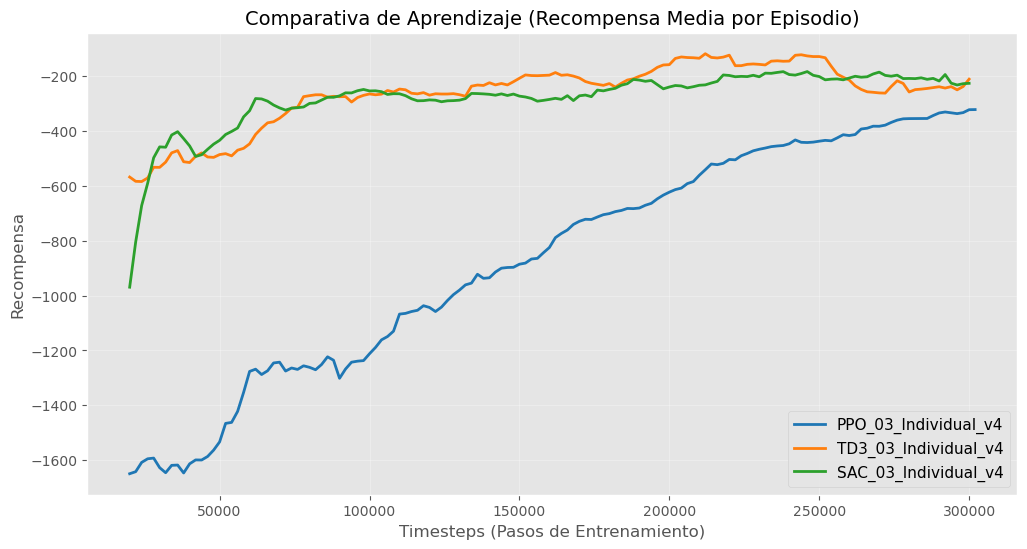

In [13]:
# ====================================================================
# VI. ANÁLISIS: EVOLUCIÓN DE LA RECOMPENSA (CURVA DE APRENDIZAJE)
# ====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def moving_average(values, window):
    """Suaviza la curva para visualizar mejor la tendencia."""
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

plt.figure(figsize=(12, 6))

# Obtenemos los nombres de los agentes automáticamente
agents_to_plot = list(AGENTS_TO_RUN.keys())

colors = ['tab:blue', 'tab:orange', 'tab:green']
print(f"--- Generando Curvas de Aprendizaje para: {agents_to_plot} ---")

for i, agent_name in enumerate(agents_to_plot):
    # Construimos la ruta al archivo de log
    log_file = os.path.join(MONITOR_LOG_DIR, f"{agent_name}.monitor.csv")
    
    if os.path.exists(log_file):
        try:
            # Saltamos la línea de metadata (#) Y la línea de cabecera (r,l,t)
            df = pd.read_csv(log_file, skiprows=2, header=None)
            
            if len(df) > 2:
                df.columns = ['r', 'l', 't'] # Asignamos nombres manualmente: reward, length, time
                
                # Convertimos a numérico por seguridad (ignora errores si queda basura)
                df['l'] = pd.to_numeric(df['l'], errors='coerce')
                df['r'] = pd.to_numeric(df['r'], errors='coerce')
                df = df.dropna() # Eliminar filas sucias si las hubiera
                
                x = df['l'].cumsum() # Pasos acumulados
                y = df['r']          # Recompensa del episodio
                
                # Suavizado dinámico
                window = max(10, len(y) // 20)
                if len(y) > window:
                    y_smooth = moving_average(y, window)
                    x_smooth = x[len(x) - len(y_smooth):]
                    plt.plot(x_smooth, y_smooth, linewidth=2, label=agent_name, color=colors[i % len(colors)])
                else:
                    plt.plot(x, y, label=agent_name, alpha=0.5)
                    
                print(f"Datos cargados para: {agent_name}")
            else:
                print(f"El archivo {agent_name} está casi vacío.")
                
        except Exception as e:
            print(f"Error leyendo log de {agent_name}: {e}")
    else:
        print(f"No se encontró el archivo log para: {agent_name} en {log_file}")

plt.title("Comparativa de Aprendizaje (Recompensa Media por Episodio)", fontsize=14)
plt.xlabel("Timesteps (Pasos de Entrenamiento)", fontsize=12)
plt.ylabel("Recompensa", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 7)VISUALIZACIÓN COMPARATIVA FINAL

--- Generando Gráficas Input-Output (Acción vs Potencia) ---

🔍 Evaluando: PPO_03_Individual_v4...


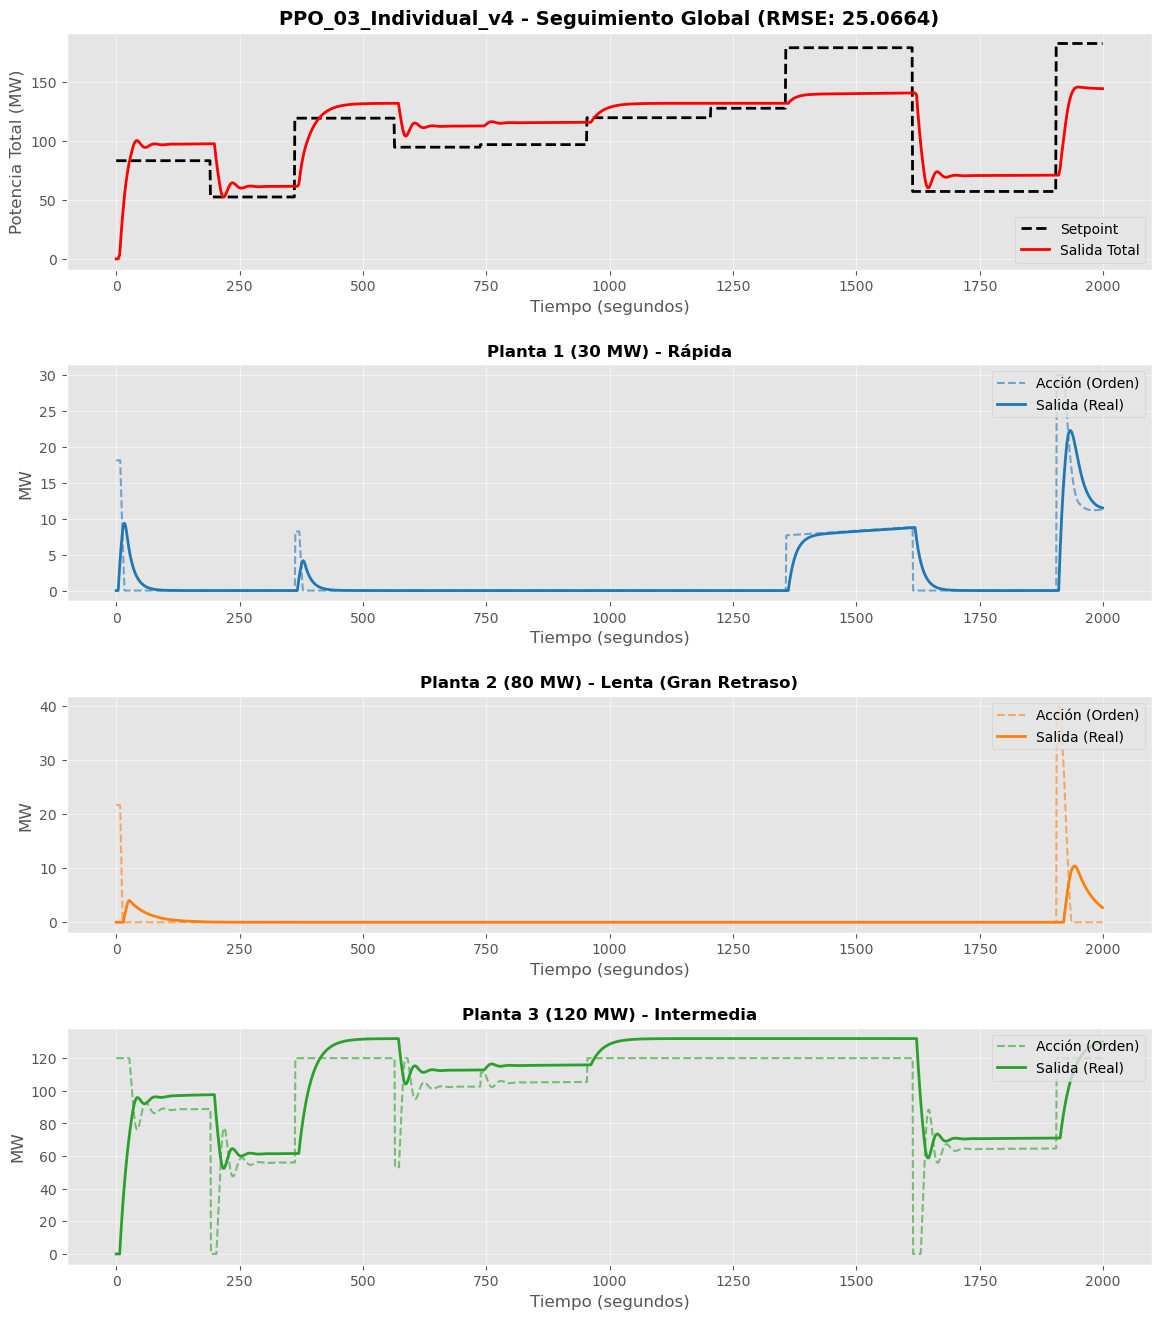


🔍 Evaluando: TD3_03_Individual_v4...


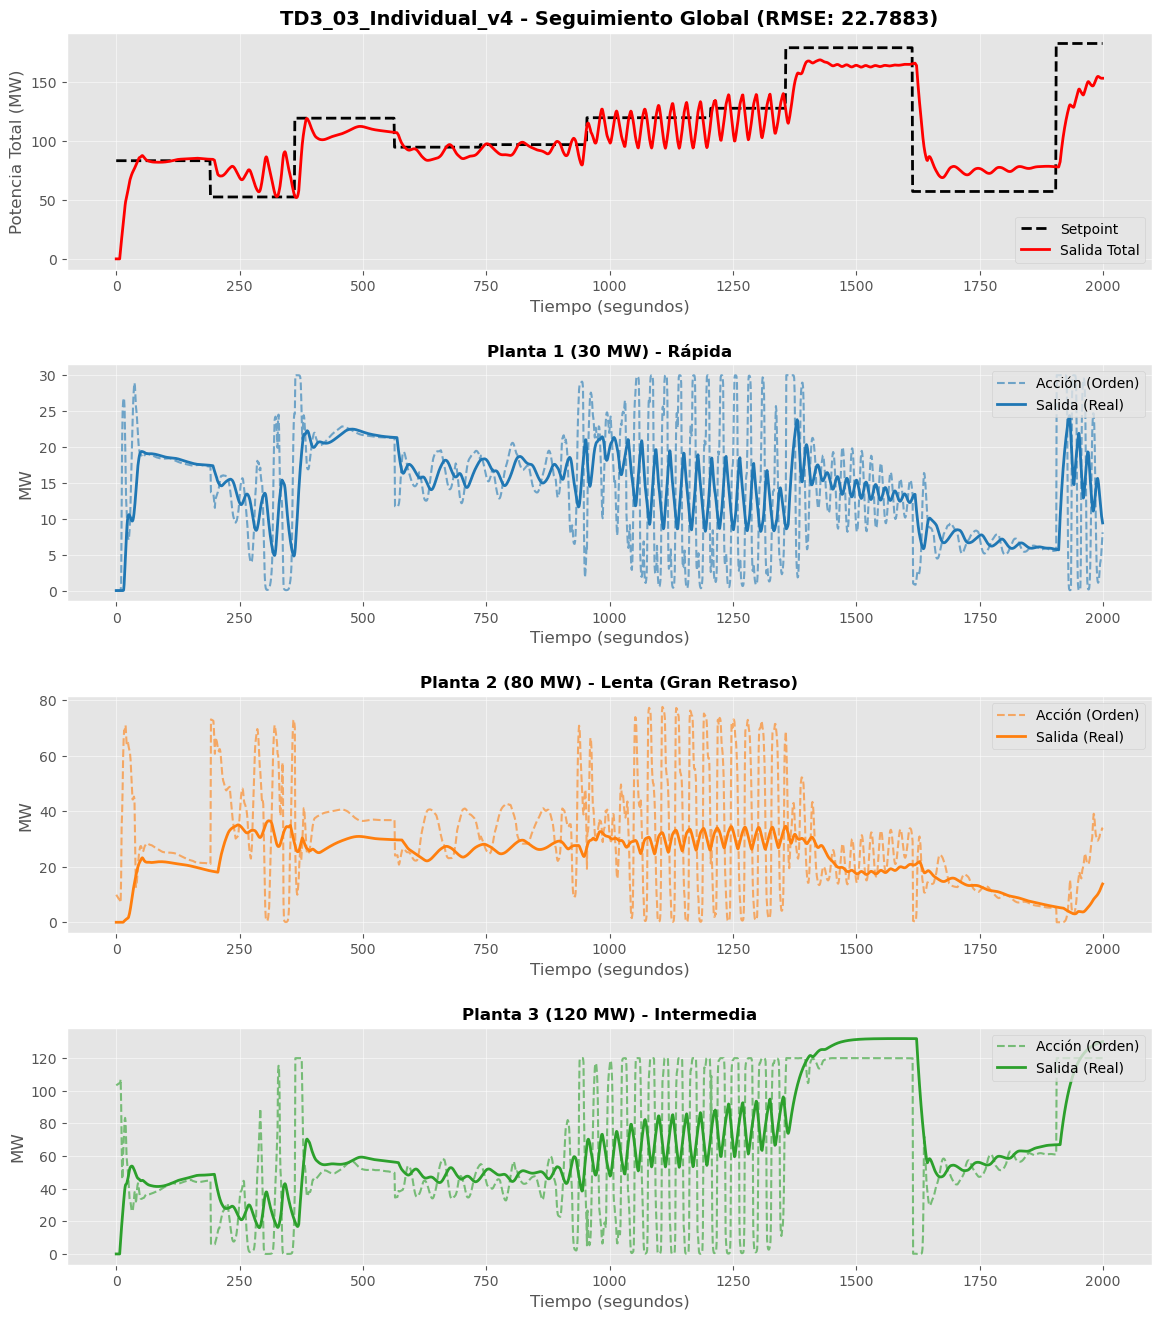


🔍 Evaluando: SAC_03_Individual_v4...


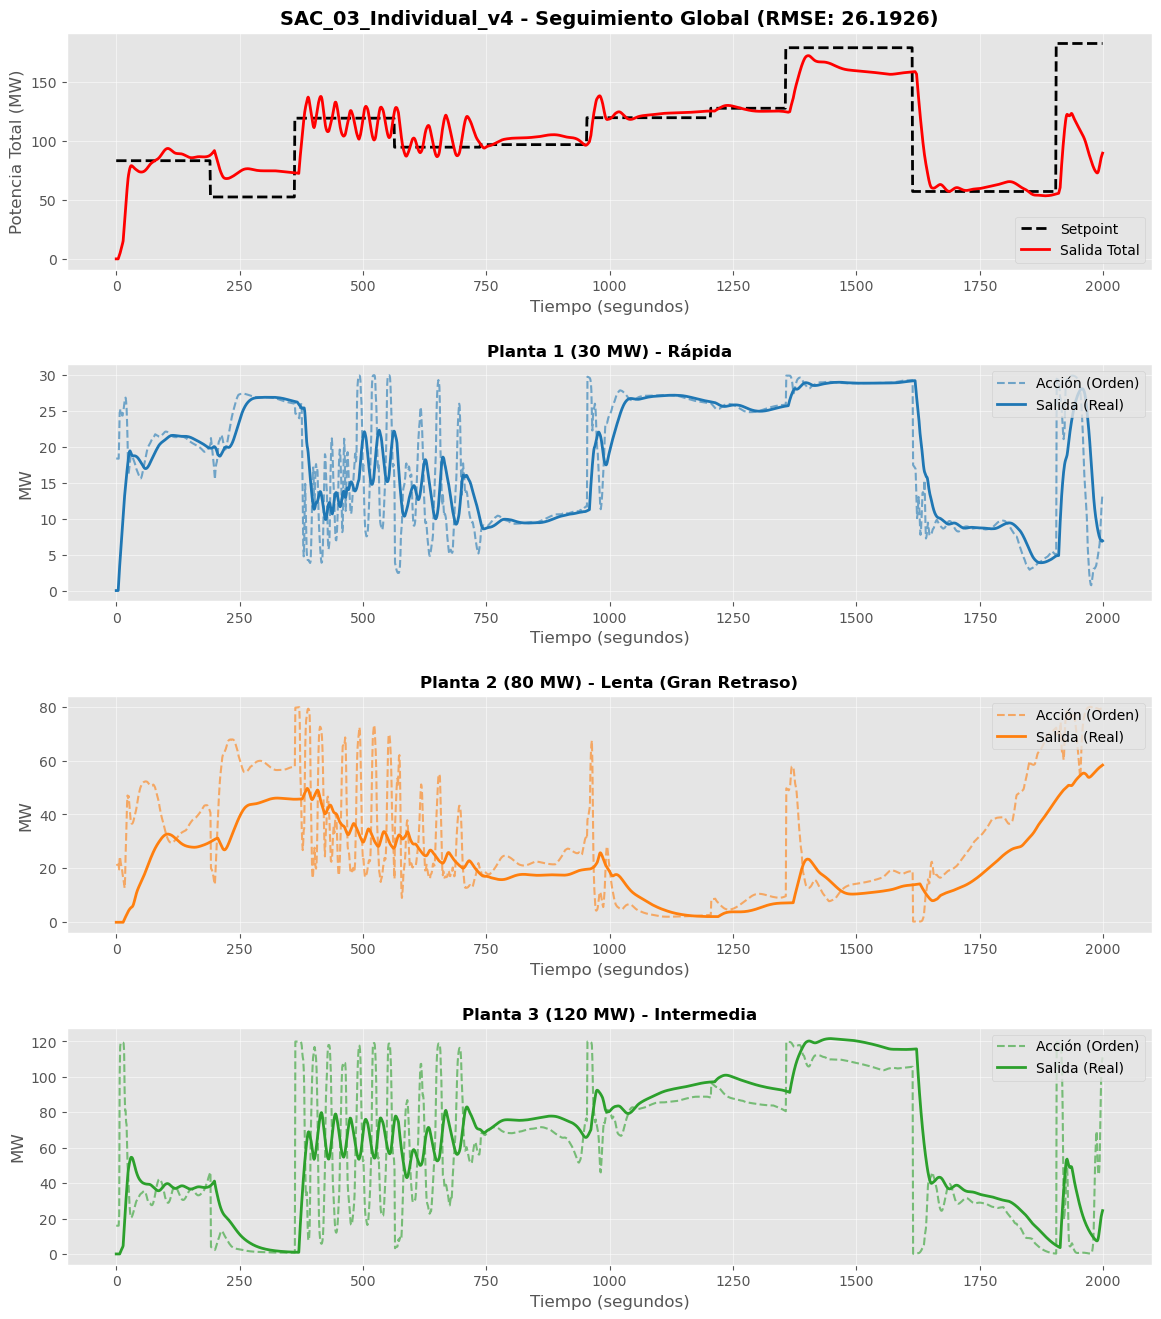

In [16]:
# ====================================================================
# VII. VISUALIZACIÓN FINAL (INPUT-OUTPUT POR PLANTA)
# ====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, TD3, SAC

print("--- Generando Gráficas Input-Output (Acción vs Potencia) ---")

# 1. CONFIGURACIÓN DEL PERFIL
def generate_slow_square_profile(length, min_val, max_val, min_step, max_step):
    profile = np.zeros(length)
    current_val = np.random.uniform(min_val, max_val)
    time = 0
    while time < length:
        step = np.random.randint(min_step, max_step)
        profile[time:min(time+step, length)] = current_val
        current_val = np.random.uniform(min_val, max_val)
        time += step
    return profile

DURATION = 2000
np.random.seed(42)
test_profile = generate_slow_square_profile(DURATION, 0.1, 0.8, 100, 300)
time_axis = np.arange(DURATION)

# 2. CARGA DE MODELOS
models_to_load = {name: cfg[0] for name, cfg in AGENTS_TO_RUN.items()}

LOCAL_DIR = "mlflow_local_artifacts"
env_eval = ThreePlantEnv() # Asegúrate de que esta clase está definida con la lógica corregida

for name, AgentClass in models_to_load.items():
    model_path = os.path.join(LOCAL_DIR, f"{name}_model.zip")
    if not os.path.exists(model_path):
        print(f"❌ NO ENCONTRADO: {model_path}"); continue

    try:
        print(f"\n🔍 Evaluando: {name}...")
        model = AgentClass.load(model_path, env=env_eval)
        obs, _ = env_eval.reset(options={'profile': test_profile})
        
        # Listas para guardar datos
        data = {
            "demanda": [], "total_out": [],
            "p1_out": [], "p2_out": [], "p3_out": [],
            "u1_mw": [], "u2_mw": [], "u3_mw": []
        }
        
        for t in range(len(test_profile)):
            action, _ = model.predict(obs, deterministic=True)
            obs, _, _, _, _ = env_eval.step(action)
            
            # Guardar Potencias (Salidas)
            plants = env_eval.plants
            data["p1_out"].append(plants[0].y_out)
            data["p2_out"].append(plants[1].y_out)
            data["p3_out"].append(plants[2].y_out)
            data["total_out"].append(sum(p.y_out for p in plants))
            data["demanda"].append(env_eval.current_setpoint_mw)
            
            # Guardar Acciones (Entradas) en MW
            # Usamos la acción que acabamos de calcular, convertida a MW
            u_mw = action * env_eval.CAPACITIES
            data["u1_mw"].append(u_mw[0])
            data["u2_mw"].append(u_mw[1])
            data["u3_mw"].append(u_mw[2])

        # RMSE Global
        rmse = np.sqrt(np.mean((np.array(data["demanda"]) - np.array(data["total_out"]))**2))

        # --- PLOTEO (4 SUBPLOTS) ---
        fig, ax = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
        
        # 1. GLOBAL
        ax[0].plot(time_axis, data["demanda"], 'k--', linewidth=2, label='Setpoint')
        ax[0].plot(time_axis, data["total_out"], 'r', linewidth=2, label='Salida Total')
        ax[0].set_title(f"{name} - Seguimiento Global (RMSE: {rmse:.4f})", fontweight='bold', fontsize=14)
        ax[0].set_ylabel("Potencia Total (MW)", fontsize=12)
        ax[0].legend(loc="lower right")
        ax[0].grid(True, alpha=0.5)
        
        # COLORES
        c_p1, c_p2, c_p3 = 'tab:blue', 'tab:orange', 'tab:green'
        
        # 2. PLANTA 1 (Rápida - 30MW)
        ax[1].plot(time_axis, data["u1_mw"], color=c_p1, linestyle='--', alpha=0.6, label='Acción (Orden)')
        ax[1].plot(time_axis, data["p1_out"], color=c_p1, linewidth=2, label='Salida (Real)')
        ax[1].set_title(f"Planta 1 (30 MW) - Rápida", fontweight='bold', fontsize=12)
        ax[1].set_ylabel("MW", fontsize=12)
        ax[1].legend(loc="upper right")
        ax[1].grid(True, alpha=0.5)
        
        # 3. PLANTA 2 (Lenta - 80MW)
        ax[2].plot(time_axis, data["u2_mw"], color=c_p2, linestyle='--', alpha=0.6, label='Acción (Orden)')
        ax[2].plot(time_axis, data["p2_out"], color=c_p2, linewidth=2, label='Salida (Real)')
        ax[2].set_title(f"Planta 2 (80 MW) - Lenta (Gran Retraso)", fontweight='bold', fontsize=12)
        ax[2].set_ylabel("MW", fontsize=12)
        ax[2].legend(loc="upper right")
        ax[2].grid(True, alpha=0.5)

        # 4. PLANTA 3 (Intermedia - 120MW)
        ax[3].plot(time_axis, data["u3_mw"], color=c_p3, linestyle='--', alpha=0.6, label='Acción (Orden)')
        ax[3].plot(time_axis, data["p3_out"], color=c_p3, linewidth=2, label='Salida (Real)')
        ax[3].set_title(f"Planta 3 (120 MW) - Intermedia", fontweight='bold', fontsize=12)
        ax[3].set_ylabel("MW", fontsize=12)
        ax[3].legend(loc="upper right")
        ax[3].grid(True, alpha=0.5)

        # Ejes X en todas
        for axis in ax:
            axis.set_xlabel("Tiempo (segundos)", fontsize=12)
            axis.tick_params(labelbottom=True)
            
        plt.subplots_adjust(hspace=0.4)
        plt.show()

    except Exception as e:
        print(f"❌ Error: {e}")